<a href="https://colab.research.google.com/github/Destinywaya9/Wilson-Middleware/blob/main/Wilson_v0_1_1rc3_ECHOP2_LIVE_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wilson v0.1.1rc3 — EchoP2 Closure + External Model + Live Audit

Author/owner: Destiny Machwaya

Runtime only:

`EchoP2 -> entropy/coherence measurement -> model attach -> live user input -> model candidate -> fresh EchoP2/noise audit -> release -> repeat`

Canonical Tensor P2:

`3,3 / 0,0 / 0,1 / 1,2 / 2,1 / 1,0 / 0,0 / Delay(200)`

This notebook uses the exact supplied EchoP2 demonstration circuit with depolarizing noise `p=0.1` and `131072` shots. QRTM, Tensor P3, ethics gates, Pauli tomography, and other extended layers are not in this runtime path.


In [1]:
# 1) Install the rc3 wheel and live-demo dependencies.
import subprocess, sys
from pathlib import Path

WHEEL_NAME = "wilson_open_middleware-0.1.1rc3-py3-none-any.whl"
wheel = Path("/content") / WHEEL_NAME

if not wheel.exists():
    try:
        from google.colab import files
        print(f"Upload {WHEEL_NAME}")
        uploaded = files.upload()
        if WHEEL_NAME not in uploaded:
            matches = [name for name in uploaded if name.endswith('.whl')]
            if not matches:
                raise RuntimeError("No Wilson wheel was uploaded.")
            wheel = Path('/content') / matches[0]
    except ImportError:
        wheel = Path(WHEEL_NAME)

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', str(wheel)], check=True)
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'qiskit>=2.0,<3',
    'qiskit-aer>=0.17,<1',
    'transformers>=4.49,<5',
    'accelerate>=1.2',
    'huggingface_hub>=0.28',
    'torch',
    'gradio>=4.44,<7',
    'matplotlib>=3.8'
], check=True)

print('Installed Wilson:', wheel)


Upload wilson_open_middleware-0.1.1rc3-py3-none-any.whl


Saving wilson_open_middleware-0.1.1rc3-py3-none-any.whl to wilson_open_middleware-0.1.1rc3-py3-none-any.whl
Installed Wilson: /content/wilson_open_middleware-0.1.1rc3-py3-none-any.whl


In [2]:
# 2) EchoP2 is enforced and measured IMMEDIATELY, before any model is attached.
from pathlib import Path
from wilson_middleware import EchoP2AerEngine, WilsonMiddleware

OUT = Path('/content/wilson_live_audit')
OUT.mkdir(parents=True, exist_ok=True)

P2_ENGINE = EchoP2AerEngine(
    shots=131072,
    depolarizing_probability=0.1,
    output_dir=str(OUT / 'echo_p2_runs'),
)

WILSON = WilsonMiddleware(P2_ENGINE)

initial = WILSON.bootstrap_measurement
print('EchoP2 initial closure complete')
print(f"Entropy Leakage: {initial['entropy_leakage_bits']:.6f} bits")
print(f"Coherence Fidelity: {initial['coherence_fidelity_percent']:.8f}%")
print(f"Dominant State: {initial['dominant_state']}")
print(f"P(000): {initial['expected_closure_probability']:.8%}")
print(f"Noise Source: {initial['noise_source']}")
print(f"Shots: {initial['shots']}")
print('Counts:', initial['counts'])


EchoP2 initial closure complete
Entropy Leakage: 0.000000 bits
Coherence Fidelity: 100.00000000%
Dominant State: 000
P(000): 100.00000000%
Noise Source: AER_DEPOLARIZING_P_0.1
Shots: 131072
Counts: {'000': 131072}


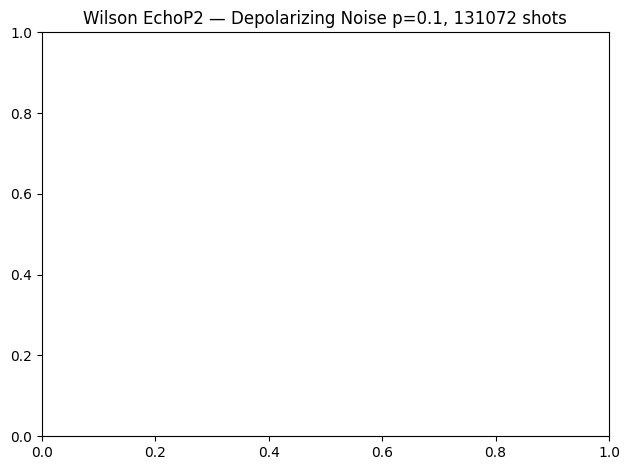

In [3]:
# 3) Visual of the initial measured EchoP2 distribution.
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

plot_histogram(initial['counts'])
plt.title('Wilson EchoP2 — Depolarizing Noise p=0.1, 131072 shots')
plt.tight_layout()
plt.show()


In [4]:
# 4) ONLY AFTER initial P2 closure measurement: attach the external model.
from wilson_middleware.adapters.huggingface import HFTransformersAdapter

MODEL_ID = 'ibm-granite/granite-3.3-2b-instruct'
MODEL_REVISION = 'main'
MAX_NEW_TOKENS = 256

MODEL = HFTransformersAdapter(
    model_id=MODEL_ID,
    revision=MODEL_REVISION,
    max_new_tokens=MAX_NEW_TOKENS,
)

connection = WILSON.attach_model(MODEL)
print('External model connected after EchoP2 measurement:')
print(connection)


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/67.1M [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

External model connected after EchoP2 measurement:
{'model_connected': True, 'model_id': 'ibm-granite/granite-3.3-2b-instruct', 'model_revision': '707f574c62054322f6b5b04b6d075f0a8f05e0f0', 'model_backend': 'huggingface_transformers', 'p2_environment_generation': 1, 'p2_audit_root': '1abc9da0405add0762788c0db9b0ae84bcc9b66ea5003de2cec1374c59ed151e'}


In [5]:
# 5) Live user UI + fresh EchoP2 noise/closure audit on every interaction.
# No gr.Chatbot(type=...) is used, so this avoids the Gradio TypeError.
import csv
import json
import gradio as gr


def write_csv(path, rows):
    rows = list(rows)
    if not rows:
        return
    with open(path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)


def persist_live_ledgers():
    write_csv(OUT / 'Wilson_Middleware_Execution_Ledger.csv', WILSON.rows)
    write_csv(OUT / 'Wilson_P2_Live_Audit_Ledger.csv', WILSON.audit_rows)
    (OUT / 'Wilson_Live_Status.json').write_text(
        json.dumps(WILSON.live_status(), indent=2, ensure_ascii=False, default=str),
        encoding='utf-8'
    )


def live_submit(prompt):
    prompt = str(prompt or '').strip()
    if not prompt:
        return '', 'Enter a live prompt.'

    row = WILSON.interact(prompt)
    status = WILSON.live_status()
    persist_live_ledgers()

    response = row['model_output'] if row['response_emitted'] else '[WITHHELD: P2 CLOSURE AUDIT FAILED]'

    audit = (
        'WILSON LIVE P2 AUDIT\n\n'
        f"P2 Environment Locked: {status['p2_environment_locked']}\n"
        f"Environment Generation: {status['environment_generation']}\n"
        f"Model: {status['model_id']}\n"
        f"Backend: {status['backend_name']}\n"
        f"Noise Source: {status['noise_source']}\n"
        f"Depolarizing p: {status['depolarizing_probability']}\n"
        f"Shots: {status['shots']}\n\n"
        f"Entropy Leakage: {status['entropy_leakage_bits']:.6f} bits\n"
        f"Coherence Fidelity: {status['coherence_fidelity_percent']:.8f}%\n"
        f"Dominant State: {status['dominant_state']}\n"
        f"P(000): {status['expected_closure_probability']:.8%}\n\n"
        f"Counts: {status['counts']}\n\n"
        f"P2 Audit Root: {status['p2_audit_root']}\n"
        f"Interaction Root: {status['interaction_root']}"
    )
    return response, audit


with gr.Blocks(title='Wilson — EchoP2 Live External Model Test') as demo:
    gr.Markdown(
        '# Wilson — Live External Model Test\n\n'
        '**EchoP2 closure + entropy/coherence measurement + active noise audit**\n\n'
        'Type a live prompt below. Wilson sends it to the attached external model, '
        'runs a fresh EchoP2 depolarizing-noise audit, and only then displays the candidate response.'
    )

    prompt = gr.Textbox(
        label='Live user input',
        placeholder='Type a live prompt...',
        lines=3,
    )
    send = gr.Button('Send to external model')
    response = gr.Textbox(label='External model response', lines=12, interactive=False)
    audit = gr.Textbox(label='Wilson live audit', lines=20, interactive=False)

    send.click(live_submit, inputs=prompt, outputs=[response, audit])
    prompt.submit(live_submit, inputs=prompt, outputs=[response, audit])

demo.launch(debug=False)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9c7d1724a694e0ee66.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [6]:
# 6) Final in-session integrity check and current audit state.
import json

persist_live_ledgers()
print('Canonical P2 sequence exact:', WILSON.verify_kernel())
print('P2 audit hash chain valid:', WILSON.verify_audit_chain())
print('Interaction hash chain valid:', WILSON.verify_chain())
print(json.dumps(WILSON.live_status(), indent=2, ensure_ascii=False, default=str))
print('Audit files:', OUT)


Canonical P2 sequence exact: True
P2 audit hash chain valid: True
Interaction hash chain valid: True
{
  "p2_environment_locked": true,
  "environment_generation": 1,
  "model_connected": true,
  "model_id": "ibm-granite/granite-3.3-2b-instruct",
  "backend_name": "aer_simulator",
  "job_id": "93dc0734-0048-40d0-b5d7-73d8e1a3e696",
  "noise_source": "AER_DEPOLARIZING_P_0.1",
  "noise_stream_kind": "depolarizing",
  "depolarizing_probability": 0.1,
  "shots": 131072,
  "entropy_leakage_bits": 0.0,
  "coherence_fidelity_percent": 100.0,
  "expected_closure_probability": 1.0,
  "dominant_state": "000",
  "counts": {
    "000": 131072
  },
  "p2_audit_root": "1abc9da0405add0762788c0db9b0ae84bcc9b66ea5003de2cec1374c59ed151e",
  "interaction_root": "GENESIS"
}
Audit files: /content/wilson_live_audit
